# Portfolio Optimization MPT

### MPT STEP 1 — CHECK STOCK PRICE DATA

In [3]:
from pathlib import Path

print("Current notebook working directory:")
print(Path.cwd())

print("\nSearching for features.parquet...")

# Search from the current project/notebook area
search_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / "OneDrive" / "Desktop",
]

found_files = []

for root in search_roots:
    if root.exists():
        for file in root.rglob("features.parquet"):
            if file not in found_files:
                found_files.append(file)

print("\nFiles found:")

if found_files:
    for file in found_files:
        print("✅", file)
else:
    print("❌ features.parquet not found")

Current notebook working directory:
c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\notebooks

Searching for features.parquet...

Files found:
✅ c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed\features.parquet


In [6]:
# MPT STEP 1C — INSPECT INDEX & PRICE DATA

print("=" * 70)
print("MPT — DATA STRUCTURE")
print("=" * 70)

print("\nIndex information:")
print("Index name:", df_mpt_check.index.name)
print("Index type:", type(df_mpt_check.index))
print("First 5 dates:")
print(df_mpt_check.index[:5])

print("\nAdjusted Close columns:")

adj_close_columns = [
    col for col in df_mpt_check.columns
    if isinstance(col, tuple) and col[0] == "Adj Close"
]

for col in adj_close_columns:
    print("✅", col)

print("\nAdjusted Close data shape:", 
      df_mpt_check[adj_close_columns].shape)

print("\nFirst 5 rows of adjusted prices:")
display(df_mpt_check[adj_close_columns].head())

MPT — DATA STRUCTURE

Index information:
Index name: Date
Index type: <class 'pandas.DatetimeIndex'>
First 5 dates:
DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08'],
              dtype='datetime64[ns]', name='Date', freq=None)

Adjusted Close columns:
✅ ('Adj Close', 'AAPL')
✅ ('Adj Close', 'CAT')
✅ ('Adj Close', 'HD')
✅ ('Adj Close', 'JNJ')
✅ ('Adj Close', 'JPM')
✅ ('Adj Close', 'KO')
✅ ('Adj Close', 'MSFT')
✅ ('Adj Close', 'NVDA')
✅ ('Adj Close', 'PG')
✅ ('Adj Close', 'XOM')
✅ ('Adj Close', '^GSPC')
✅ ('Adj Close', '^VIX')

Adjusted Close data shape: (2936, 12)

First 5 rows of adjusted prices:


Price       Adj Close                                                         \
Ticker           AAPL        CAT         HD        JNJ        JPM         KO   
Date                                                                           
2015-01-02  24.171755  68.899345  78.204041  75.737366  46.066788  29.390263   
2015-01-05  23.490805  65.262398  76.563309  75.208389  44.636635  29.390263   
2015-01-06  23.493017  64.842461  76.328911  74.838837  43.479263  29.613441   
2015-01-07  23.822432  65.847313  78.945038  76.490990  43.545609  29.983099   
2015-01-08  24.737753  66.522217  80.691635  77.092400  44.518696  30.345751   

Price                                                                          
Ticker           MSFT      NVDA         PG        XOM        ^GSPC       ^VIX  
Date                                                                           
2015-01-02  39.607178  0.482423  65.069992  56.777901  2058.199951  17.790001  
2015-01-05  39.242962  0.474275  64.760643  55.224365  2020.579956  19.920000  
2015-01-06  38.666973  0.459895  64.465637  54.930759  2002.609985  21.120001  
2015-01-07  39.158257  0.458697  64.803787  55.487362  2025.900024  19.309999  
2015-01-08  40.310219  0.475952  65.544853  56.410934  2062.139893  17.010000

In [7]:
# MPT STEP 2 — BUILD DAILY RETURN PANEL

import numpy as np
import pandas as pd

stocks = ["AAPL", "MSFT", "JPM", "XOM", "JNJ", "PG", "NVDA", "KO", "CAT", "HD"]
benchmark = "^GSPC"

# Extract adjusted close prices
price_columns = [("Adj Close", stock) for stock in stocks + [benchmark]]

prices = df_mpt_check[price_columns].copy()

# Rename columns from MultiIndex → simple ticker names
prices.columns = stocks + [benchmark]

# Make sure dates are sorted
prices = prices.sort_index()

# Calculate daily percentage returns
portfolio_returns = prices.pct_change()

# Remove first row because it has no previous trading day
portfolio_returns = portfolio_returns.dropna(how="all")

print("=" * 70)
print("MPT — DAILY RETURN PANEL")
print("=" * 70)

print(f"Price panel shape:   {prices.shape}")
print(f"Return panel shape:  {portfolio_returns.shape}")

print(f"\nDate range:")
print(f"{portfolio_returns.index.min()} → {portfolio_returns.index.max()}")

print("\nMissing values:")
print(portfolio_returns.isna().sum())

print("\nFirst 5 daily returns:")
display(portfolio_returns.head())

print("\nReturn statistics:")
display(portfolio_returns[stocks].describe().T[["mean", "std", "min", "max"]])

MPT — DAILY RETURN PANEL
Price panel shape:   (2936, 11)
Return panel shape:  (2935, 11)

Date range:
2015-01-05 00:00:00 → 2026-09-04 00:00:00

Missing values:
AAPL     0
MSFT     0
JPM      0
XOM      0
JNJ      0
PG       0
NVDA     0
KO       0
CAT      0
HD       0
^GSPC    0
dtype: int64

First 5 daily returns:


,AAPL,MSFT,JPM,XOM,JNJ,PG,NVDA,KO,CAT,HD,^GSPC
Date,,,,,,,,,,,
2015-01-05,-0.028171,-0.009196,-0.031045,-0.027362,-0.006984,-0.004754,-0.016890,0.000000,-0.052786,-0.020980,-0.018278
2015-01-06,0.000094,-0.014678,-0.025929,-0.005317,-0.004914,-0.004555,-0.030318,0.007594,-0.006435,-0.003061,-0.008893
2015-01-07,0.014022,0.012706,0.001526,0.010133,0.022076,0.005245,-0.002605,0.012483,0.015497,0.034274,0.011630
2015-01-08,0.038423,0.029418,0.022346,0.016645,0.007862,0.011436,0.037618,0.012095,0.010250,0.022124,0.017888
2015-01-09,0.001072,-0.008405,-0.017387,-0.001410,-0.013629,-0.009330,0.004028,-0.011032,-0.011950,-0.017148,-0.008404



Return statistics:


,mean,std,min,max
AAPL,0.001044,0.018110,-0.128647,0.153288
MSFT,0.001015,0.017390,-0.147390,0.155067
JPM,0.000843,0.016955,-0.149649,0.180125
XOM,0.000502,0.017319,-0.122248,0.126868
JNJ,0.000507,0.011562,-0.100379,0.079977
PG,0.000345,0.011755,-0.087373,0.120090
NVDA,0.002560,0.030358,-0.187558,0.298067
KO,0.000438,0.011280,-0.096725,0.064796
CAT,0.001030,0.019410,-0.142822,0.116346
HD,0.000600,0.015373,-0.197938,0.137508


In [4]:
# MPT STEP 3 — BUILD RETURNS + ANNUALIZED STATISTICS
from pathlib import Path
import numpy as np
import pandas as pd

# PROJECT + DATA

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

FEATURES_PATH = (
    PROJECT_ROOT / "data" / "processed" / "features.parquet")

df_mpt = pd.read_parquet(FEATURES_PATH)

# PORTFOLIO UNIVERSE

stocks = [
    "AAPL", "MSFT", "JPM", "XOM", "JNJ",
    "PG", "NVDA", "KO", "CAT", "HD"]

TRADING_DAYS = 252

# EXTRACT ADJUSTED CLOSE

price_columns = [
    ("Adj Close", stock)
    for stock in stocks]

prices = df_mpt[price_columns].copy()

prices.columns = stocks
prices = prices.sort_index()

# DAILY RETURNS

portfolio_returns = prices.pct_change().dropna()

# ANNUALIZED RETURN

annual_return = portfolio_returns.mean() * TRADING_DAYS

# ANNUALIZED VOLATILITY

annual_volatility = (
    portfolio_returns.std() * np.sqrt(TRADING_DAYS))

# 5. SUMMARY TABLE

asset_statistics = pd.DataFrame({
    "Annual_Return": annual_return,
    "Annual_Volatility": annual_volatility})

asset_statistics_display = pd.DataFrame({
    "Annual Return (%)":
        asset_statistics["Annual_Return"] * 100,

    "Annual Volatility (%)":
        asset_statistics["Annual_Volatility"] * 100})

asset_statistics_display = (
    asset_statistics_display
    .sort_values("Annual Return (%)", ascending=False))

print("=" * 70)
print("MPT — ANNUALIZED RETURN & VOLATILITY")
print("=" * 70)

print(f"\nPrice observations: {len(prices)}")
print(f"Return observations: {len(portfolio_returns)}")

print(
    f"Period: "
    f"{portfolio_returns.index.min().date()} → "
    f"{portfolio_returns.index.max().date()}")

print("\nAnnualized asset statistics:")
display(asset_statistics_display.round(3))



MPT — ANNUALIZED RETURN & VOLATILITY

Price observations: 2936
Return observations: 2935
Period: 2015-01-05 → 2026-09-04

Annualized asset statistics:


,Annual Return (%),Annual Volatility (%)
NVDA,64.521,48.192
AAPL,26.315,28.749
CAT,25.958,30.812
MSFT,25.573,27.606
JPM,21.241,26.916
HD,15.132,24.404
JNJ,12.768,18.354
XOM,12.649,27.493
KO,11.034,17.906
PG,8.705,18.660


In [5]:
# MPT STEP 4 — COVARIANCE MATRIX

# Daily covariance matrix
covariance_daily = portfolio_returns[stocks].cov()

# Annualized covariance matrix
covariance_annual = covariance_daily * TRADING_DAYS

print("=" * 70)
print("MPT — ANNUALIZED COVARIANCE MATRIX")
print("=" * 70)

print("\nAnnualized covariance matrix:")
display(covariance_annual.round(4))

# Basic validation

print("\nValidation checks:")

print(
    "Matrix shape:",
    covariance_annual.shape)

print(
    "Symmetric:",
    np.allclose(
        covariance_annual.values,
        covariance_annual.values.T))

print(
    "Missing values:",
    covariance_annual.isna().sum().sum())

MPT — ANNUALIZED COVARIANCE MATRIX

Annualized covariance matrix:


,AAPL,MSFT,JPM,XOM,JNJ,PG,NVDA,KO,CAT,HD
AAPL,0.0826,0.0491,0.0319,0.0224,0.0159,0.0185,0.0702,0.0170,0.0321,0.0335
MSFT,0.0491,0.0762,0.0309,0.0182,0.0143,0.0174,0.0764,0.0157,0.0282,0.0318
JPM,0.0319,0.0309,0.0724,0.0375,0.0173,0.0154,0.0433,0.0189,0.0480,0.0313
XOM,0.0224,0.0182,0.0375,0.0756,0.0150,0.0117,0.0235,0.0176,0.0411,0.0193
JNJ,0.0159,0.0143,0.0173,0.0150,0.0337,0.0178,0.0096,0.0164,0.0149,0.0164
PG,0.0185,0.0174,0.0154,0.0117,0.0178,0.0348,0.0135,0.0206,0.0123,0.0195
NVDA,0.0702,0.0764,0.0433,0.0235,0.0096,0.0135,0.2322,0.0114,0.0519,0.0450
KO,0.0170,0.0157,0.0189,0.0176,0.0164,0.0206,0.0114,0.0321,0.0143,0.0185
CAT,0.0321,0.0282,0.0480,0.0411,0.0149,0.0123,0.0519,0.0143,0.0949,0.0309
HD,0.0335,0.0318,0.0313,0.0193,0.0164,0.0195,0.0450,0.0185,0.0309,0.0596



Validation checks:
Matrix shape: (10, 10)
Symmetric: True
Missing values: 0


In [6]:
# MPT STEP 5 — MANUAL PORTFOLIO MATHEMATICS
# Equal-Weight Portfolio

# Equal weight: 10 stocks → 10% each
weights = np.ones(len(stocks)) / len(stocks)

# Convert to Series for readability
weights_series = pd.Series(weights, index=stocks, name="Weight")

# 1. Portfolio Expected Annual Return
#
# Formula:
# Rp = w' × μ

portfolio_return_manual = (
    weights @ annual_return.loc[stocks].values)

# 2. Portfolio Annualized Volatility
#
# Formula:
# σp = sqrt(w' × Σ × w)

portfolio_variance_manual = (
    weights
    @ covariance_annual.loc[stocks, stocks].values
    @ weights)

portfolio_volatility_manual = np.sqrt(
    portfolio_variance_manual)

# 3. Sharpe Ratio
#
# For now risk-free rate = 0
#
# Sharpe = (Rp - Rf) / σp

risk_free_rate = 0.0

sharpe_manual = (
    (portfolio_return_manual - risk_free_rate)
    / portfolio_volatility_manual)

# OUTPUT

print("=" * 70)
print("MPT — MANUAL PORTFOLIO MATHEMATICS")
print("=" * 70)

print("\nEqual-weight portfolio:")
display(
    pd.DataFrame({
        "Weight (%)": weights * 100
    }, index=stocks).round(2))

print("\nPortfolio Results:")
print(
    f"Expected Annual Return : "
    f"{portfolio_return_manual * 100:.3f}%")

print(
    f"Annual Volatility      : "
    f"{portfolio_volatility_manual * 100:.3f}%")

print(
    f"Sharpe Ratio           : "
    f"{sharpe_manual:.4f}")

print(
    f"\nWeights sum to: "
    f"{weights.sum():.4f}")

MPT — MANUAL PORTFOLIO MATHEMATICS

Equal-weight portfolio:


,Weight (%)
AAPL,10.0
MSFT,10.0
JPM,10.0
XOM,10.0
JNJ,10.0
PG,10.0
NVDA,10.0
KO,10.0
CAT,10.0
HD,10.0



Portfolio Results:
Expected Annual Return : 22.390%
Annual Volatility      : 17.741%
Sharpe Ratio           : 1.2620

Weights sum to: 1.0000


In [7]:
# MPT STEP 6 — VERIFY MANUAL PORTFOLIO CALCULATIONS
# ============================================================

# ------------------------------------------------------------
# Independent calculation from the daily return series
# ------------------------------------------------------------

# Historical equal-weight portfolio daily returns
equal_weight_daily_returns = (
    portfolio_returns[stocks]
    @ weights)

# Annualized realized return
realized_annual_return = (
    equal_weight_daily_returns.mean() * TRADING_DAYS)

# Annualized realized volatility
realized_annual_volatility = (
    equal_weight_daily_returns.std()
    * np.sqrt(TRADING_DAYS))

# Sharpe ratio
realized_sharpe = (
    realized_annual_return - risk_free_rate
) / realized_annual_volatility

# Compare manual vs independent calculation

verification = pd.DataFrame({
    "Manual": [
        portfolio_return_manual,
        portfolio_volatility_manual,
        sharpe_manual],
    "Independent": [
        realized_annual_return,
        realized_annual_volatility,
        realized_sharpe]
}, index=[
    "Annual Return",
    "Annual Volatility",
    "Sharpe Ratio"])

verification["Absolute Difference"] = (
    verification["Manual"]
    - verification["Independent"]
).abs()

print("=" * 70)
print("MPT — MANUAL vs INDEPENDENT VERIFICATION")
print("=" * 70)

display(verification)

print("\nMaximum absolute difference:",
      f"{verification['Absolute Difference'].max():.12f}")

MPT — MANUAL vs INDEPENDENT VERIFICATION


,Manual,Independent,Absolute Difference
Annual Return,0.223895,0.223895,2.775558e-17
Annual Volatility,0.177406,0.177406,0.000000e+00
Sharpe Ratio,1.262047,1.262047,2.220446e-16



Maximum absolute difference: 0.000000000000


In [8]:
# MPT STEP 7 — MONTE CARLO PORTFOLIO SIMULATION

np.random.seed(42)

N_PORTFOLIOS = 10_000

# Storage
simulation_results = np.zeros((N_PORTFOLIOS, 3))
simulation_weights = np.zeros((N_PORTFOLIOS, len(stocks)))

# Annualized expected returns and covariance matrix
mu = annual_return.loc[stocks].values
cov_matrix = covariance_annual.loc[stocks, stocks].values

# Generate random portfolios

for i in range(N_PORTFOLIOS):

    # Random positive weights
    random_weights = np.random.random(len(stocks))

    # Normalize so weights sum to 1
    random_weights /= random_weights.sum()

    # Portfolio return
    port_return = random_weights @ mu

    # Portfolio volatility
    port_variance = (
        random_weights
        @ cov_matrix
        @ random_weights)

    port_volatility = np.sqrt(port_variance)

    # Sharpe ratio
    port_sharpe = (
        port_return - risk_free_rate
    ) / port_volatility

    simulation_results[i] = [
        port_return,
        port_volatility,
        port_sharpe]

    simulation_weights[i] = random_weights

# Create simulation DataFrame

simulation_df = pd.DataFrame(
    simulation_results,
    columns=[
        "Annual_Return",
        "Annual_Volatility",
        "Sharpe_Ratio"])

weights_df = pd.DataFrame(
    simulation_weights,
    columns=stocks)

# Identify best random portfolios

max_sharpe_idx = simulation_df["Sharpe_Ratio"].idxmax()
min_vol_idx = simulation_df["Annual_Volatility"].idxmin()

best_random_portfolio = simulation_df.loc[max_sharpe_idx]
lowest_vol_portfolio = simulation_df.loc[min_vol_idx]

print("=" * 70)
print("MPT — MONTE CARLO PORTFOLIO SIMULATION")
print("=" * 70)

print(f"\nPortfolios simulated: {N_PORTFOLIOS:,}")

print("\nBest random portfolio by Sharpe:")
print(f"Annual Return     : {best_random_portfolio['Annual_Return'] * 100:.3f}%")
print(f"Annual Volatility : {best_random_portfolio['Annual_Volatility'] * 100:.3f}%")
print(f"Sharpe Ratio      : {best_random_portfolio['Sharpe_Ratio']:.4f}")

print("\nBest random portfolio weights:")
display(
    pd.DataFrame({
        "Weight (%)":
            weights_df.loc[max_sharpe_idx] * 100
    }).round(3))

print("\nLowest-volatility random portfolio:")
print(f"Annual Return     : {lowest_vol_portfolio['Annual_Return'] * 100:.3f}%")
print(f"Annual Volatility : {lowest_vol_portfolio['Annual_Volatility'] * 100:.3f}%")
print(f"Sharpe Ratio      : {lowest_vol_portfolio['Sharpe_Ratio']:.4f}")

MPT — MONTE CARLO PORTFOLIO SIMULATION

Portfolios simulated: 10,000

Best random portfolio by Sharpe:
Annual Return     : 27.657%
Annual Volatility : 19.158%
Sharpe Ratio      : 1.4436

Best random portfolio weights:


,Weight (%)
AAPL,0.625
MSFT,2.951
JPM,8.707
XOM,2.875
JNJ,26.799
PG,2.044
NVDA,26.640
KO,25.461
CAT,3.118
HD,0.779



Lowest-volatility random portfolio:
Annual Return     : 14.885%
Annual Volatility : 14.940%
Sharpe Ratio      : 0.9963


In [9]:
# MPT STEP 8 — MAXIMUM SHARPE PORTFOLIO OPTIMIZATION

from scipy.optimize import minimize

mu = annual_return.loc[stocks].values
cov_matrix = covariance_annual.loc[stocks, stocks].values

n_assets = len(stocks)

# Start from equal weights
initial_weights = np.ones(n_assets) / n_assets

# Portfolio functions

def portfolio_return(weights):
    return weights @ mu


def portfolio_volatility(weights):
    variance = weights @ cov_matrix @ weights
    return np.sqrt(variance)


def portfolio_sharpe(weights):
    return (
        portfolio_return(weights) - risk_free_rate
    ) / portfolio_volatility(weights)


# Optimization objective

def negative_sharpe(weights):
    return -portfolio_sharpe(weights)


# Constraints

# All weights must sum to 100%
constraints = [
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1}]

# Long-only portfolio: no negative weights
bounds = tuple(
    (0, 1)
    for _ in range(n_assets))

# Run optimizer

optimization_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "ftol": 1e-12,
        "maxiter": 2000,
        "disp": False})

if not optimization_result.success:
    print("⚠️ Optimization warning:")
    print(optimization_result.message)

optimized_weights = optimization_result.x

# Optimized portfolio metrics

optimized_return = portfolio_return(optimized_weights)
optimized_volatility = portfolio_volatility(optimized_weights)
optimized_sharpe = portfolio_sharpe(optimized_weights)

optimized_weights_df = pd.DataFrame({
    "Weight (%)": optimized_weights * 100
}, index=stocks)

# Compare portfolios

equal_weight_sharpe = portfolio_sharpe(initial_weights)
equal_weight_return = portfolio_return(initial_weights)
equal_weight_volatility = portfolio_volatility(initial_weights)

comparison = pd.DataFrame({
    "Annual Return (%)": [
        equal_weight_return * 100,
        best_random_portfolio["Annual_Return"] * 100,
        optimized_return * 100],
    "Annual Volatility (%)": [
        equal_weight_volatility * 100,
        best_random_portfolio["Annual_Volatility"] * 100,
        optimized_volatility * 100],
    "Sharpe Ratio": [
        equal_weight_sharpe,
        best_random_portfolio["Sharpe_Ratio"],
        optimized_sharpe]
}, index=[
    "Equal Weight",
    "Monte Carlo Best",
    "Optimized Max-Sharpe"])


print("=" * 70)
print("MPT — MAXIMUM SHARPE PORTFOLIO")
print("=" * 70)

print("\nOptimization status:")
print("Success:", optimization_result.success)
print("Message:", optimization_result.message)

print("\nOptimized portfolio weights:")
display(optimized_weights_df.round(4))

print(
    f"\nWeight sum: "
    f"{optimized_weights.sum():.10f}")

print("\nOptimized portfolio:")
print(
    f"Annual Return     : {optimized_return * 100:.3f}%")
print(
    f"Annual Volatility : {optimized_volatility * 100:.3f}%")
print(
    f"Sharpe Ratio      : {optimized_sharpe:.4f}")

print("\nPortfolio comparison:")
display(comparison.round(4))

MPT — MAXIMUM SHARPE PORTFOLIO

Optimization status:
Success: True
Message: Optimization terminated successfully

Optimized portfolio weights:


,Weight (%)
AAPL,2.8210
MSFT,0.0000
JPM,1.7787
XOM,0.0000
JNJ,32.1881
PG,0.0000
NVDA,36.0121
KO,14.5958
CAT,12.6043
HD,0.0000



Weight sum: 1.0000000000

Optimized portfolio:
Annual Return     : 33.348%
Annual Volatility : 22.469%
Sharpe Ratio      : 1.4842

Portfolio comparison:


,Annual Return (%),Annual Volatility (%),Sharpe Ratio
Equal Weight,22.3895,17.7406,1.2620
Monte Carlo Best,27.6571,19.1580,1.4436
Optimized Max-Sharpe,33.3476,22.4689,1.4842


#### MPT STEP 9 — EFFICIENT FRONTIER VISUALIZATION

findfont: Failed to find font weight heavy, now using 700.
findfont: Failed to find font weight heavy, now using 700.


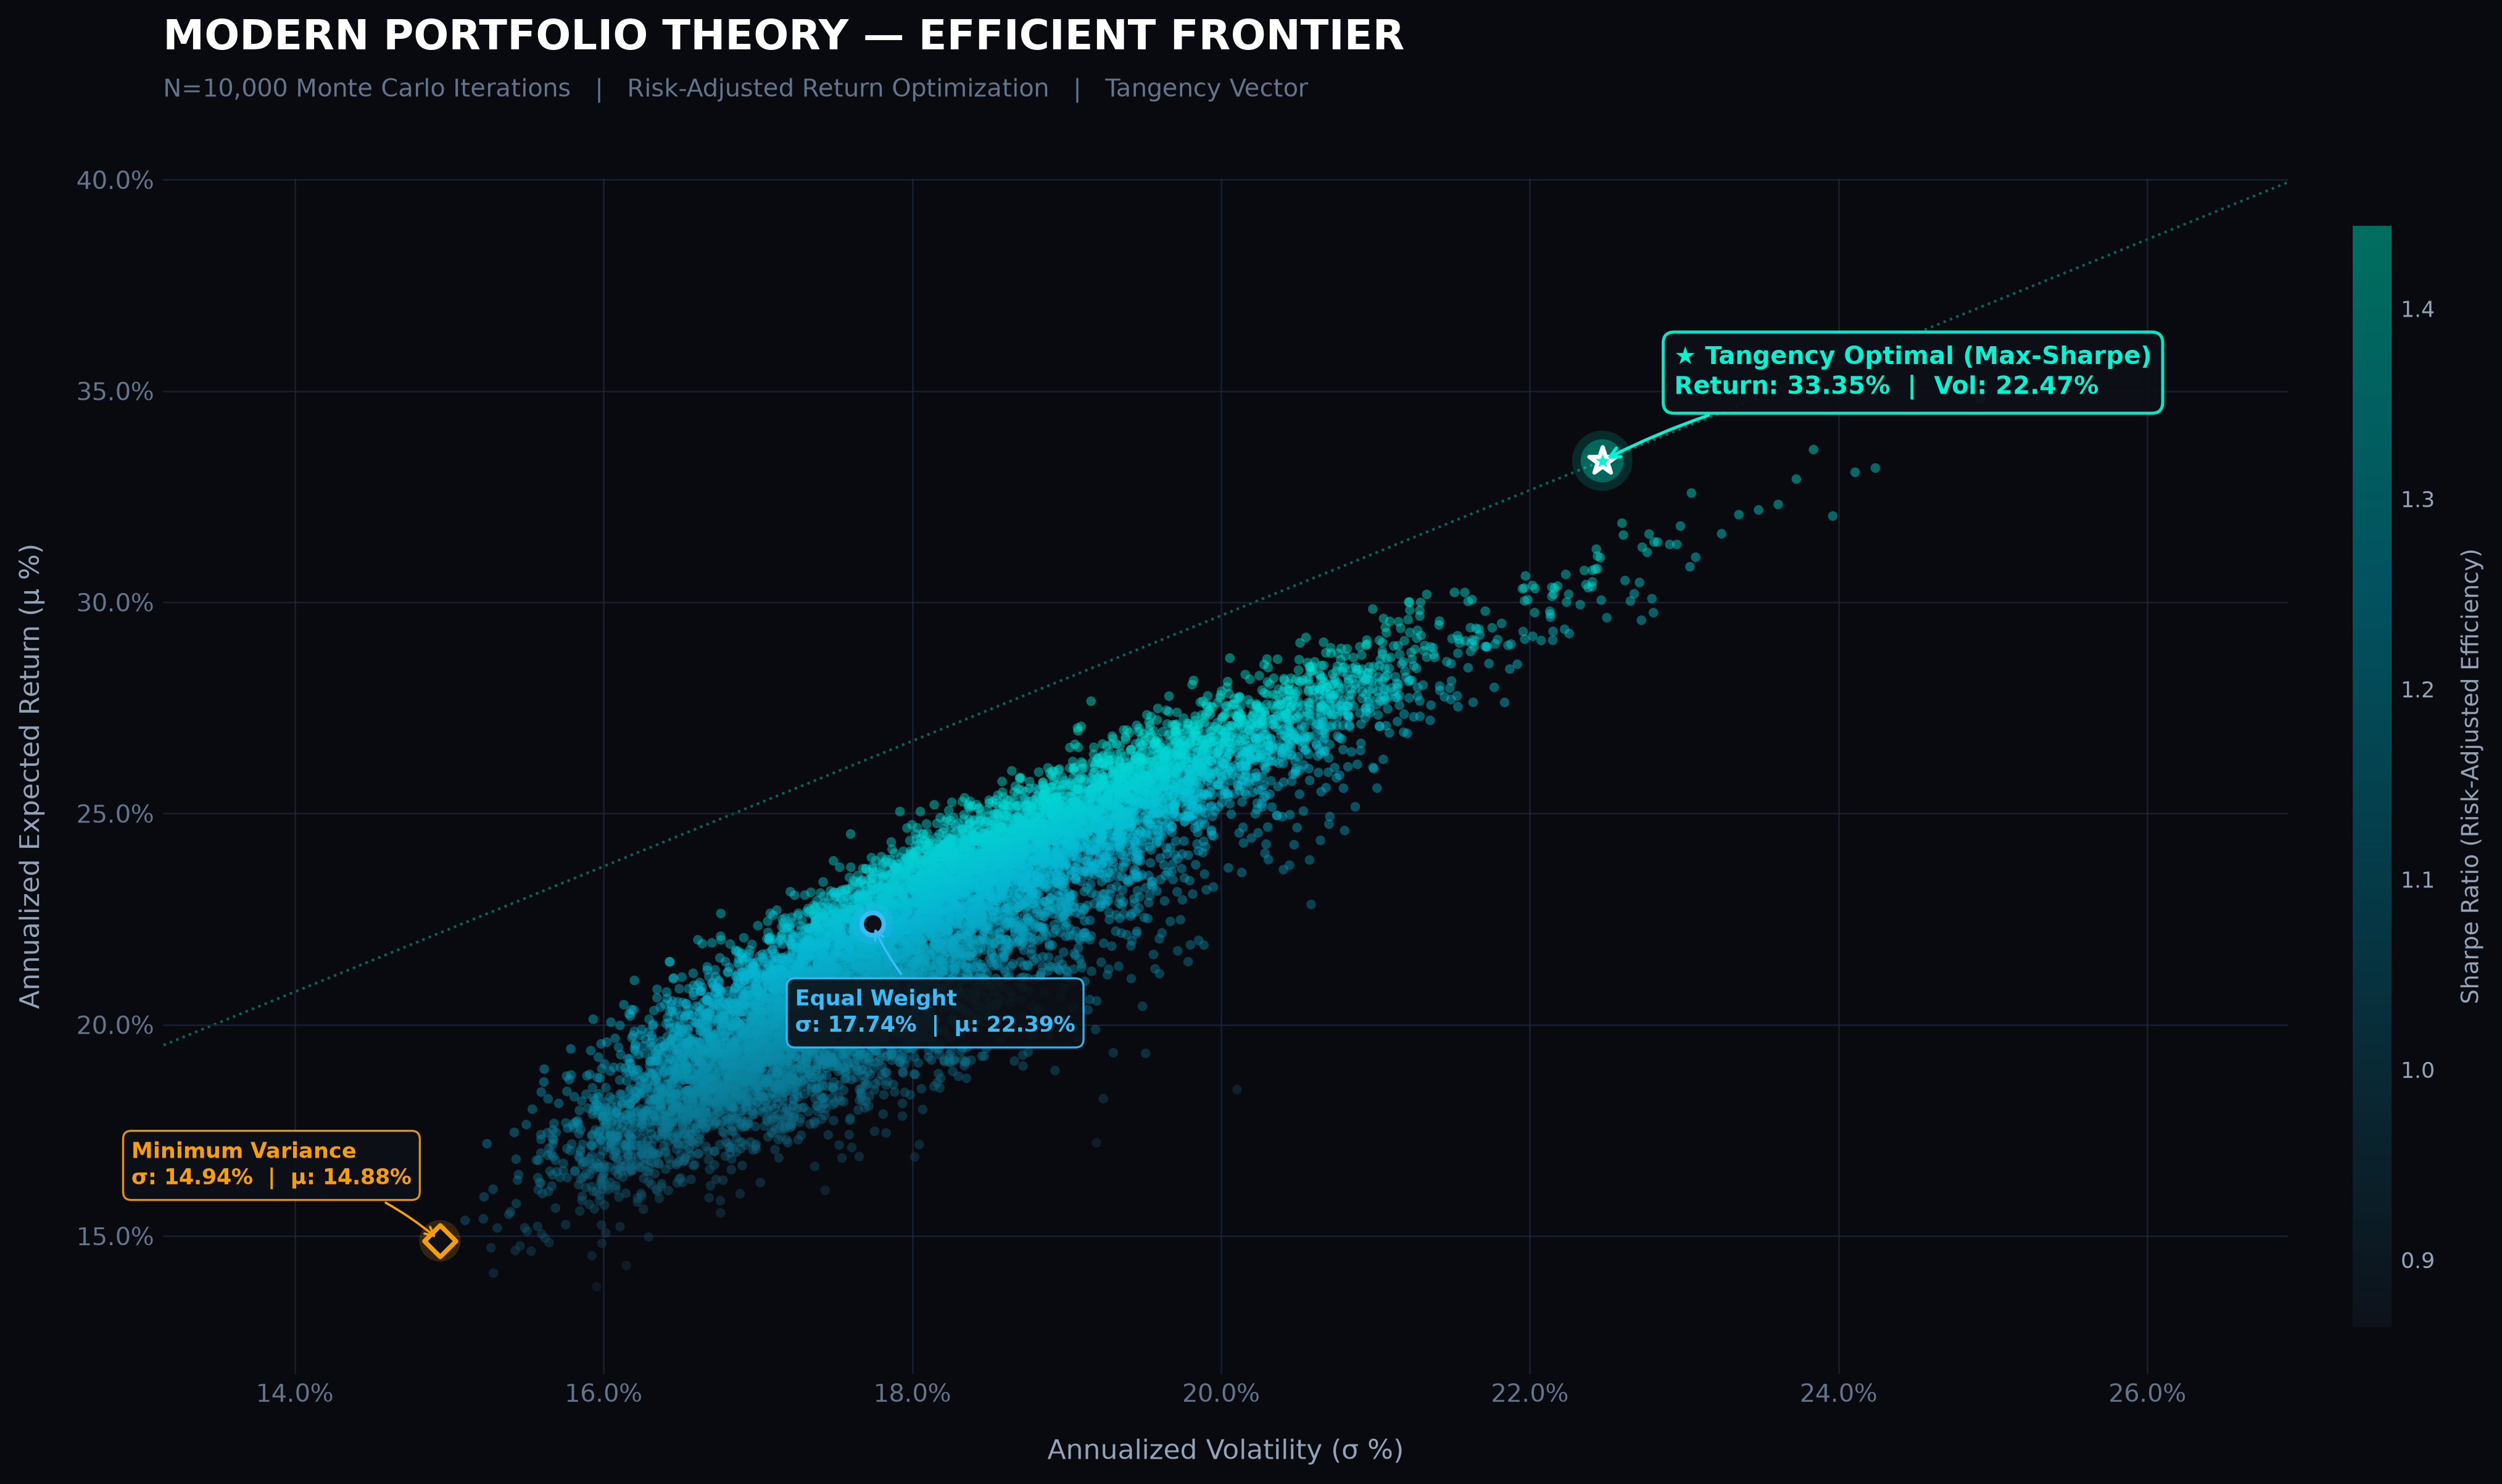

✔ QUANTITATIVE EFFICIENT FRONTIER EXPORTED
PNG Image : C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\portfolio\efficient_frontier_monte_carlo.png
Vector PDF: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\portfolio\efficient_frontier_monte_carlo.pdf


In [10]:
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Canvas & Obsidian Dark Theme
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(14, 8.5), dpi=300)
fig.patch.set_facecolor("#080A0F")
ax.set_facecolor("#080A0F")

# Custom Quant Colormap: Deep Midnight Navy -> Slate Cyan -> Electric Neon Teal
quant_cmap = LinearSegmentedColormap.from_list(
    "quant_frontier",
    ["#1E293B", "#0E7490", "#06B6D4", "#00F5D4"],
    N=256,)

# Coordinate extractions
vol_sim = simulation_df["Annual_Volatility"].values * 100
ret_sim = simulation_df["Annual_Return"].values * 100
sharpe_sim = simulation_df["Sharpe_Ratio"].values

eq_vol = float(equal_weight_volatility) * 100
eq_ret = float(equal_weight_return) * 100

low_vol = float(lowest_vol_portfolio["Annual_Volatility"]) * 100
low_ret = float(lowest_vol_portfolio["Annual_Return"]) * 100

max_vol = float(optimized_volatility) * 100
max_ret = float(optimized_return) * 100

# 2. Monte Carlo Density Simulation Scatter
scatter = ax.scatter(
    vol_sim,
    ret_sim,
    c=sharpe_sim,
    cmap=quant_cmap,
    s=14,
    alpha=0.45,
    edgecolors="none",
    zorder=2,)

# 3. Benchmark Anchors: Glow Pinpoints

# [A] Equal Weight Portfolio (Muted Sky Blue)
ax.scatter([eq_vol], [eq_ret], s=260, color="#38BDF8", alpha=0.18, edgecolors="none", zorder=3)
ax.scatter([eq_vol], [eq_ret], s=75, color="#0D1117", edgecolors="#38BDF8", linewidths=1.8, marker="o", zorder=4)

# [B] Minimum Volatility Portfolio (Warm Amber)
ax.scatter([low_vol], [low_ret], s=260, color="#F59E0B", alpha=0.18, edgecolors="none", zorder=3)
ax.scatter([low_vol], [low_ret], s=75, color="#0D1117", edgecolors="#F59E0B", linewidths=1.8, marker="D", zorder=4)

# [C] Max Sharpe Tangency Portfolio (Glowing Neon Cyan + Outer Pulse)
ax.scatter([max_vol], [max_ret], s=550, color="#00F5D4", alpha=0.14, edgecolors="none", zorder=3)
ax.scatter([max_vol], [max_ret], s=280, color="#00F5D4", alpha=0.30, edgecolors="none", zorder=4)
ax.scatter([max_vol], [max_ret], s=120, color="#00F5D4", edgecolors="#FFFFFF", linewidths=1.6, marker="*", zorder=5)

# Capital Allocation Tangency Line (Origin to Max Sharpe)
ax.plot(
    [0, max_vol * 1.35],
    [0, max_ret * 1.35],
    color="#00F5D4",
    linestyle=":",
    linewidth=1.0,
    alpha=0.4,
    zorder=1,)

# 4. Glassmorphic Callout Cards

# Equal Weight Callout
ax.annotate(
    f"Equal Weight\nσ: {eq_vol:.2f}%  |  μ: {eq_ret:.2f}%",
    xy=(eq_vol, eq_ret),
    xytext=(-30, -42),
    textcoords="offset points",
    fontsize=8.5,
    fontweight="bold",
    color="#38BDF8",
    bbox=dict(boxstyle="round,pad=0.38", fc="#0D1117", ec="#38BDF8", lw=0.8, alpha=0.92),
    arrowprops=dict(arrowstyle="->", color="#38BDF8", lw=0.9, connectionstyle="arc3,rad=-0.1"),
    zorder=6,)

# Lowest Volatility Callout
ax.annotate(
    f"Minimum Variance\nσ: {low_vol:.2f}%  |  μ: {low_ret:.2f}%",
    xy=(low_vol, low_ret),
    xytext=(-120, 22),
    textcoords="offset points",
    fontsize=8.5,
    fontweight="bold",
    color="#F59E0B",
    bbox=dict(boxstyle="round,pad=0.38", fc="#0D1117", ec="#F59E0B", lw=0.8, alpha=0.92),
    arrowprops=dict(arrowstyle="->", color="#F59E0B", lw=0.9, connectionstyle="arc3,rad=-0.15"),
    zorder=6,)

# Max Sharpe Optimal Callout
max_sr = max_ret / max_vol if max_vol > 0 else 0
ax.annotate(
    f"★ Tangency Optimal (Max-Sharpe)\nReturn: {max_ret:.2f}%  |  Vol: {max_vol:.2f}%",
    xy=(max_vol, max_ret),
    xytext=(28, 26),
    textcoords="offset points",
    fontsize=9.5,
    fontweight="heavy",
    color="#00F5D4",
    bbox=dict(boxstyle="round,pad=0.45", fc="#0D1117", ec="#00F5D4", lw=1.2, alpha=0.95),
    arrowprops=dict(arrowstyle="->", color="#00F5D4", lw=1.2, connectionstyle="arc3,rad=0.1"),
    zorder=6,)

# 5. Executive Headers & Metadata
fig.text(
    0.07,
    0.962,
    "MODERN PORTFOLIO THEORY — EFFICIENT FRONTIER",
    fontsize=16,
    fontweight="heavy",
    color="#FFFFFF",
    ha="left",)
fig.text(
    0.07,
    0.932,
    f"N={len(simulation_df):,} Monte Carlo Iterations   |   Risk-Adjusted Return Optimization   |   Tangency Vector",
    fontsize=9.5,
    color="#64748B",
    ha="left",)

# 6. Axes, Gridlines & Minimal Ticks

ax.grid(True, which="major", color="#1E293B", linestyle="-", linewidth=0.65, alpha=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", which="both", colors="#64748B", labelsize=9.5, length=0)
ax.set_xlabel("Annualized Volatility (σ %)", color="#94A3B8", fontsize=10.5, labelpad=12)
ax.set_ylabel("Annualized Expected Return (μ %)", color="#94A3B8", fontsize=10.5, labelpad=12)

ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))

# Buffer boundaries
ax.set_xlim(min(vol_sim) * 0.88, max(vol_sim) * 1.08)
ax.set_ylim(min(ret_sim) * 0.85, max(ret_sim) * 1.15)

# 7. Floating Colorbar & Artifact Export

cbar_ax = fig.add_axes([0.915, 0.15, 0.015, 0.70])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=8.5, colors="#94A3B8", length=0)
cbar.set_label("Sharpe Ratio (Risk-Adjusted Efficiency)", color="#94A3B8", fontsize=9, labelpad=10)

plt.subplots_adjust(top=0.88, bottom=0.12, left=0.07, right=0.89)

RESULTS_DIR = Path(globals().get("PROJECT_ROOT", ".")) / "results" / "portfolio"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

frontier_png = RESULTS_DIR / "efficient_frontier_monte_carlo.png"
frontier_pdf = RESULTS_DIR / "efficient_frontier_monte_carlo.pdf"

plt.savefig(frontier_png, dpi=300, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")
plt.savefig(frontier_pdf, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")

plt.show()
plt.close()

print("=" * 70)
print("✔ QUANTITATIVE EFFICIENT FRONTIER EXPORTED")
print("=" * 70)
print(f"PNG Image : {frontier_png.resolve()}")
print(f"Vector PDF: {frontier_pdf.resolve()}")

In [12]:
# MPT STEP 10 — PORTFOLIO RISK METRICS
# Standalone + Benchmark Included

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

FEATURES_PATH = (
    PROJECT_ROOT / "data" / "processed" / "features.parquet")

df_risk = pd.read_parquet(FEATURES_PATH)

stocks = [
    "AAPL", "MSFT", "JPM", "XOM", "JNJ",
    "PG", "NVDA", "KO", "CAT", "HD"]

benchmark = "^GSPC"
TRADING_DAYS = 252
rf = 0.0

assets = stocks + [benchmark]

price_columns = [
    ("Adj Close", asset)
    for asset in assets]

prices_risk = df_risk[price_columns].copy()

prices_risk.columns = assets
prices_risk = prices_risk.sort_index()

returns_risk = prices_risk.pct_change().dropna()

optimized_daily_returns = (
    returns_risk[stocks] @ optimized_weights)

equal_weight_daily_returns = (
    returns_risk[stocks] @ initial_weights)

benchmark_returns = returns_risk[benchmark]

def calculate_max_drawdown(returns):

    wealth = (1 + returns).cumprod()

    running_peak = wealth.cummax()

    drawdown = (
        wealth / running_peak
    ) - 1

    return drawdown.min()

def calculate_sortino(returns, risk_free=0.0):

    daily_rf = risk_free / TRADING_DAYS

    excess_returns = returns - daily_rf

    downside_returns = excess_returns[
        excess_returns < 0]

    downside_deviation = (
        np.sqrt((downside_returns ** 2).mean())
        * np.sqrt(TRADING_DAYS))

    annualized_excess_return = (
        excess_returns.mean()
        * TRADING_DAYS)

    return (
        annualized_excess_return
        / downside_deviation)


def calculate_beta(portfolio, benchmark):

    aligned = pd.concat(
        [portfolio, benchmark],
        axis=1
    ).dropna()

    covariance = np.cov(
        aligned.iloc[:, 0],
        aligned.iloc[:, 1],
        ddof=1
    )[0, 1]

    benchmark_variance = np.var(
        aligned.iloc[:, 1],
        ddof=1)

    return covariance / benchmark_variance

portfolio_series = {
    "Optimized Max-Sharpe": optimized_daily_returns,
    "Equal Weight": equal_weight_daily_returns,
    "S&P 500": benchmark_returns}

risk_results = []

for name, returns in portfolio_series.items():

    annualized_return = (
        returns.mean()
        * TRADING_DAYS)

    annualized_volatility = (
        returns.std()
        * np.sqrt(TRADING_DAYS))

    sharpe = (
        annualized_return - rf
    ) / annualized_volatility

    sortino = calculate_sortino(
        returns,
        risk_free=rf)

    max_drawdown = calculate_max_drawdown(
        returns)

    # Beta of S&P 500 against itself should be ~1
    beta = calculate_beta(
        returns,
        benchmark_returns)

    risk_results.append([
        name,
        annualized_return,
        annualized_volatility,
        sharpe,
        sortino,
        max_drawdown,
        beta])

risk_metrics = pd.DataFrame(
    risk_results,
    columns=[
        "Portfolio",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Maximum Drawdown",
        "Beta"]
).set_index("Portfolio")

risk_metrics_display = risk_metrics.copy()

risk_metrics_display["Annual Return"] *= 100
risk_metrics_display["Annual Volatility"] *= 100
risk_metrics_display["Maximum Drawdown"] *= 100

print("=" * 75)
print("MPT — PORTFOLIO RISK METRICS")
print("=" * 75)

print(
    f"\nAnalysis period: "
    f"{returns_risk.index.min().date()} → "
    f"{returns_risk.index.max().date()}")

print(
    f"Trading observations: "
    f"{len(returns_risk):,}")

print("\nRisk comparison:")
display(
    risk_metrics_display.round(4))

MPT — PORTFOLIO RISK METRICS

Analysis period: 2015-01-05 → 2026-09-04
Trading observations: 2,935

Risk comparison:


,Annual Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Beta
Portfolio,,,,,,
Optimized Max-Sharpe,33.3476,22.4689,1.4842,1.5032,-31.9625,1.0512
Equal Weight,22.3895,17.7406,1.2620,1.2076,-32.8834,0.9501
S&P 500,12.9187,17.6781,0.7308,0.6960,-33.9250,1.0000


In [13]:
# MPT STEP 11 — OUT-OF-SAMPLE BACKTEST SETUP
# Train: 2015-01-05 → 2025-01-09
# Test : 2025-01-10 → 2026-09-04

from scipy.optimize import minimize

BACKTEST_START = "2025-01-10"

assets = stocks + ["^GSPC"]

price_columns = [
    ("Adj Close", asset)
    for asset in assets]

prices_backtest = df_risk[price_columns].copy()
prices_backtest.columns = assets
prices_backtest = prices_backtest.sort_index()

returns_backtest = prices_backtest.pct_change().dropna()

train_returns = returns_backtest.loc[
    returns_backtest.index < BACKTEST_START
].copy()

test_returns = returns_backtest.loc[
    returns_backtest.index >= BACKTEST_START
].copy()

train_stock_returns = train_returns[stocks]

train_mu = (
    train_stock_returns.mean()
    * TRADING_DAYS)

train_covariance = (
    train_stock_returns.cov()
    * TRADING_DAYS)

mu_train = train_mu.values
cov_train = train_covariance.loc[
    stocks, stocks
].values

n_assets = len(stocks)

initial_weights_oos = (
    np.ones(n_assets) / n_assets)

def train_portfolio_return(weights):
    return weights @ mu_train


def train_portfolio_volatility(weights):
    variance = (
        weights
        @ cov_train
        @ weights)
    return np.sqrt(variance)


def train_portfolio_sharpe(weights):
    return (
        train_portfolio_return(weights) - rf
    ) / train_portfolio_volatility(weights)


def negative_train_sharpe(weights):
    return -train_portfolio_sharpe(weights)


constraints_oos = [
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1}]

bounds_oos = tuple(
    (0, 1)
    for _ in range(n_assets))

oos_optimization = minimize(
    negative_train_sharpe,
    initial_weights_oos,
    method="SLSQP",
    bounds=bounds_oos,
    constraints=constraints_oos,
    options={
        "ftol": 1e-12,
        "maxiter": 2000,
        "disp": False})

oos_weights = oos_optimization.x

print("=" * 75)
print("MPT — OUT-OF-SAMPLE BACKTEST SETUP")
print("=" * 75)

print("\nOptimization success:")
print(oos_optimization.success)

print("\nOptimization message:")
print(oos_optimization.message)

print("\nTRAIN period:")
print(
    train_returns.index.min().date(),
    "→",
    train_returns.index.max().date())

print("\nTEST period:")
print(
    test_returns.index.min().date(),
    "→",
    test_returns.index.max().date())

print("\nTrain observations:", len(train_returns))
print("Test observations :", len(test_returns))

print("\nTRAIN-ONLY optimized weights:")
display(
    pd.DataFrame(
        {"Weight (%)": oos_weights * 100},
        index=stocks
    ).round(4))

print(
    "\nWeight sum:",
    f"{oos_weights.sum():.10f}")

print("\nTRAIN-ONLY optimized metrics:")

train_opt_return = train_portfolio_return(oos_weights)
train_opt_volatility = train_portfolio_volatility(oos_weights)
train_opt_sharpe = train_portfolio_sharpe(oos_weights)

print(
    f"Annual Return     : {train_opt_return * 100:.3f}%")
print(
    f"Annual Volatility : {train_opt_volatility * 100:.3f}%")
print(
    f"Sharpe Ratio      : {train_opt_sharpe:.4f}")

MPT — OUT-OF-SAMPLE BACKTEST SETUP

Optimization success:
True

Optimization message:
Optimization terminated successfully

TRAIN period:
2015-01-05 → 2025-01-08

TEST period:
2025-01-10 → 2026-09-04

Train observations: 2520
Test observations : 415

TRAIN-ONLY optimized weights:


,Weight (%)
AAPL,8.9193
MSFT,0.4872
JPM,12.0222
XOM,0.0000
JNJ,0.0000
PG,20.5300
NVDA,51.5018
KO,0.0000
CAT,6.5395
HD,0.0000



Weight sum: 1.0000000000

TRAIN-ONLY optimized metrics:
Annual Return     : 43.701%
Annual Volatility : 30.016%
Sharpe Ratio      : 1.4559


In [14]:
# MPT STEP 12 — TRUE OUT-OF-SAMPLE BACKTEST
# Frozen TRAIN-ONLY Weights

# 1. Apply frozen weights ONLY to test period

optimized_test_returns = (
    test_returns[stocks] @ oos_weights)

equal_weight_test_returns = (
    test_returns[stocks] @ initial_weights_oos)

benchmark_test_returns = (
    test_returns["^GSPC"])

# 2. Portfolio wealth curves

initial_capital = 100_000

optimized_wealth = (
    initial_capital
    * (1 + optimized_test_returns).cumprod())

equal_weight_wealth = (
    initial_capital
    * (1 + equal_weight_test_returns).cumprod())

benchmark_wealth = (
    initial_capital
    * (1 + benchmark_test_returns).cumprod())

# 3. OOS metric helper

def calculate_oos_metrics(
    returns,
    benchmark,
    risk_free=0.0
):

    annual_return = (
        returns.mean()
        * TRADING_DAYS)

    annual_volatility = (
        returns.std()
        * np.sqrt(TRADING_DAYS))

    sharpe = (
        annual_return - risk_free
    ) / annual_volatility

    sortino = calculate_sortino(
        returns,
        risk_free=risk_free)

    max_drawdown = calculate_max_drawdown(
        returns)

    beta = calculate_beta(
        returns,
        benchmark)

    total_return = (
        (1 + returns).prod() - 1)

    return {
        "Total Return": total_return,
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": max_drawdown,
        "Beta": beta}

# 4. Calculate OOS metrics

oos_results = {}

oos_results["Optimized Max-Sharpe"] = calculate_oos_metrics(
    optimized_test_returns,
    benchmark_test_returns)

oos_results["Equal Weight"] = calculate_oos_metrics(
    equal_weight_test_returns,
    benchmark_test_returns)

oos_results["S&P 500"] = calculate_oos_metrics(
    benchmark_test_returns,
    benchmark_test_returns)

oos_metrics = pd.DataFrame(oos_results).T

# 5. Display percentage metrics

oos_display = oos_metrics.copy()

for col in [
    "Total Return",
    "Annual Return",
    "Annual Volatility",
    "Maximum Drawdown"
]:
    oos_display[col] *= 100

print("=" * 75)
print("MPT — TRUE OUT-OF-SAMPLE BACKTEST")
print("=" * 75)

print(
    f"\nTEST PERIOD: "
    f"{test_returns.index.min().date()} → "
    f"{test_returns.index.max().date()}")

print(
    f"Initial Capital: "
    f"₹{initial_capital:,.0f}")

print("\nPerformance comparison:")
display(oos_display.round(4))

# 6. Final portfolio values

final_values = pd.DataFrame({
    "Final Portfolio Value (₹)": [
        optimized_wealth.iloc[-1],
        equal_weight_wealth.iloc[-1],
        benchmark_wealth.iloc[-1]
    ]
}, index=[
    "Optimized Max-Sharpe",
    "Equal Weight",
    "S&P 500"])

print("\nFinal portfolio values:")
display(final_values.round(2))

MPT — TRUE OUT-OF-SAMPLE BACKTEST

TEST PERIOD: 2025-01-10 → 2026-09-04
Initial Capital: ₹100,000

Performance comparison:


,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Beta
Optimized Max-Sharpe,54.1371,29.8275,26.7194,1.1163,1.1160,-24.7847,1.3303
Equal Weight,50.6346,25.8400,13.8422,1.8668,1.8844,-15.4951,0.7258
S&P 500,30.4203,17.5350,16.8162,1.0427,1.0306,-18.9022,1.0000



Final portfolio values:


,Final Portfolio Value (₹)
Optimized Max-Sharpe,154137.14
Equal Weight,150634.58
S&P 500,130420.31


#### MPT STEP 13 — OUT-OF-SAMPLE CUMULATIVE WEALTH

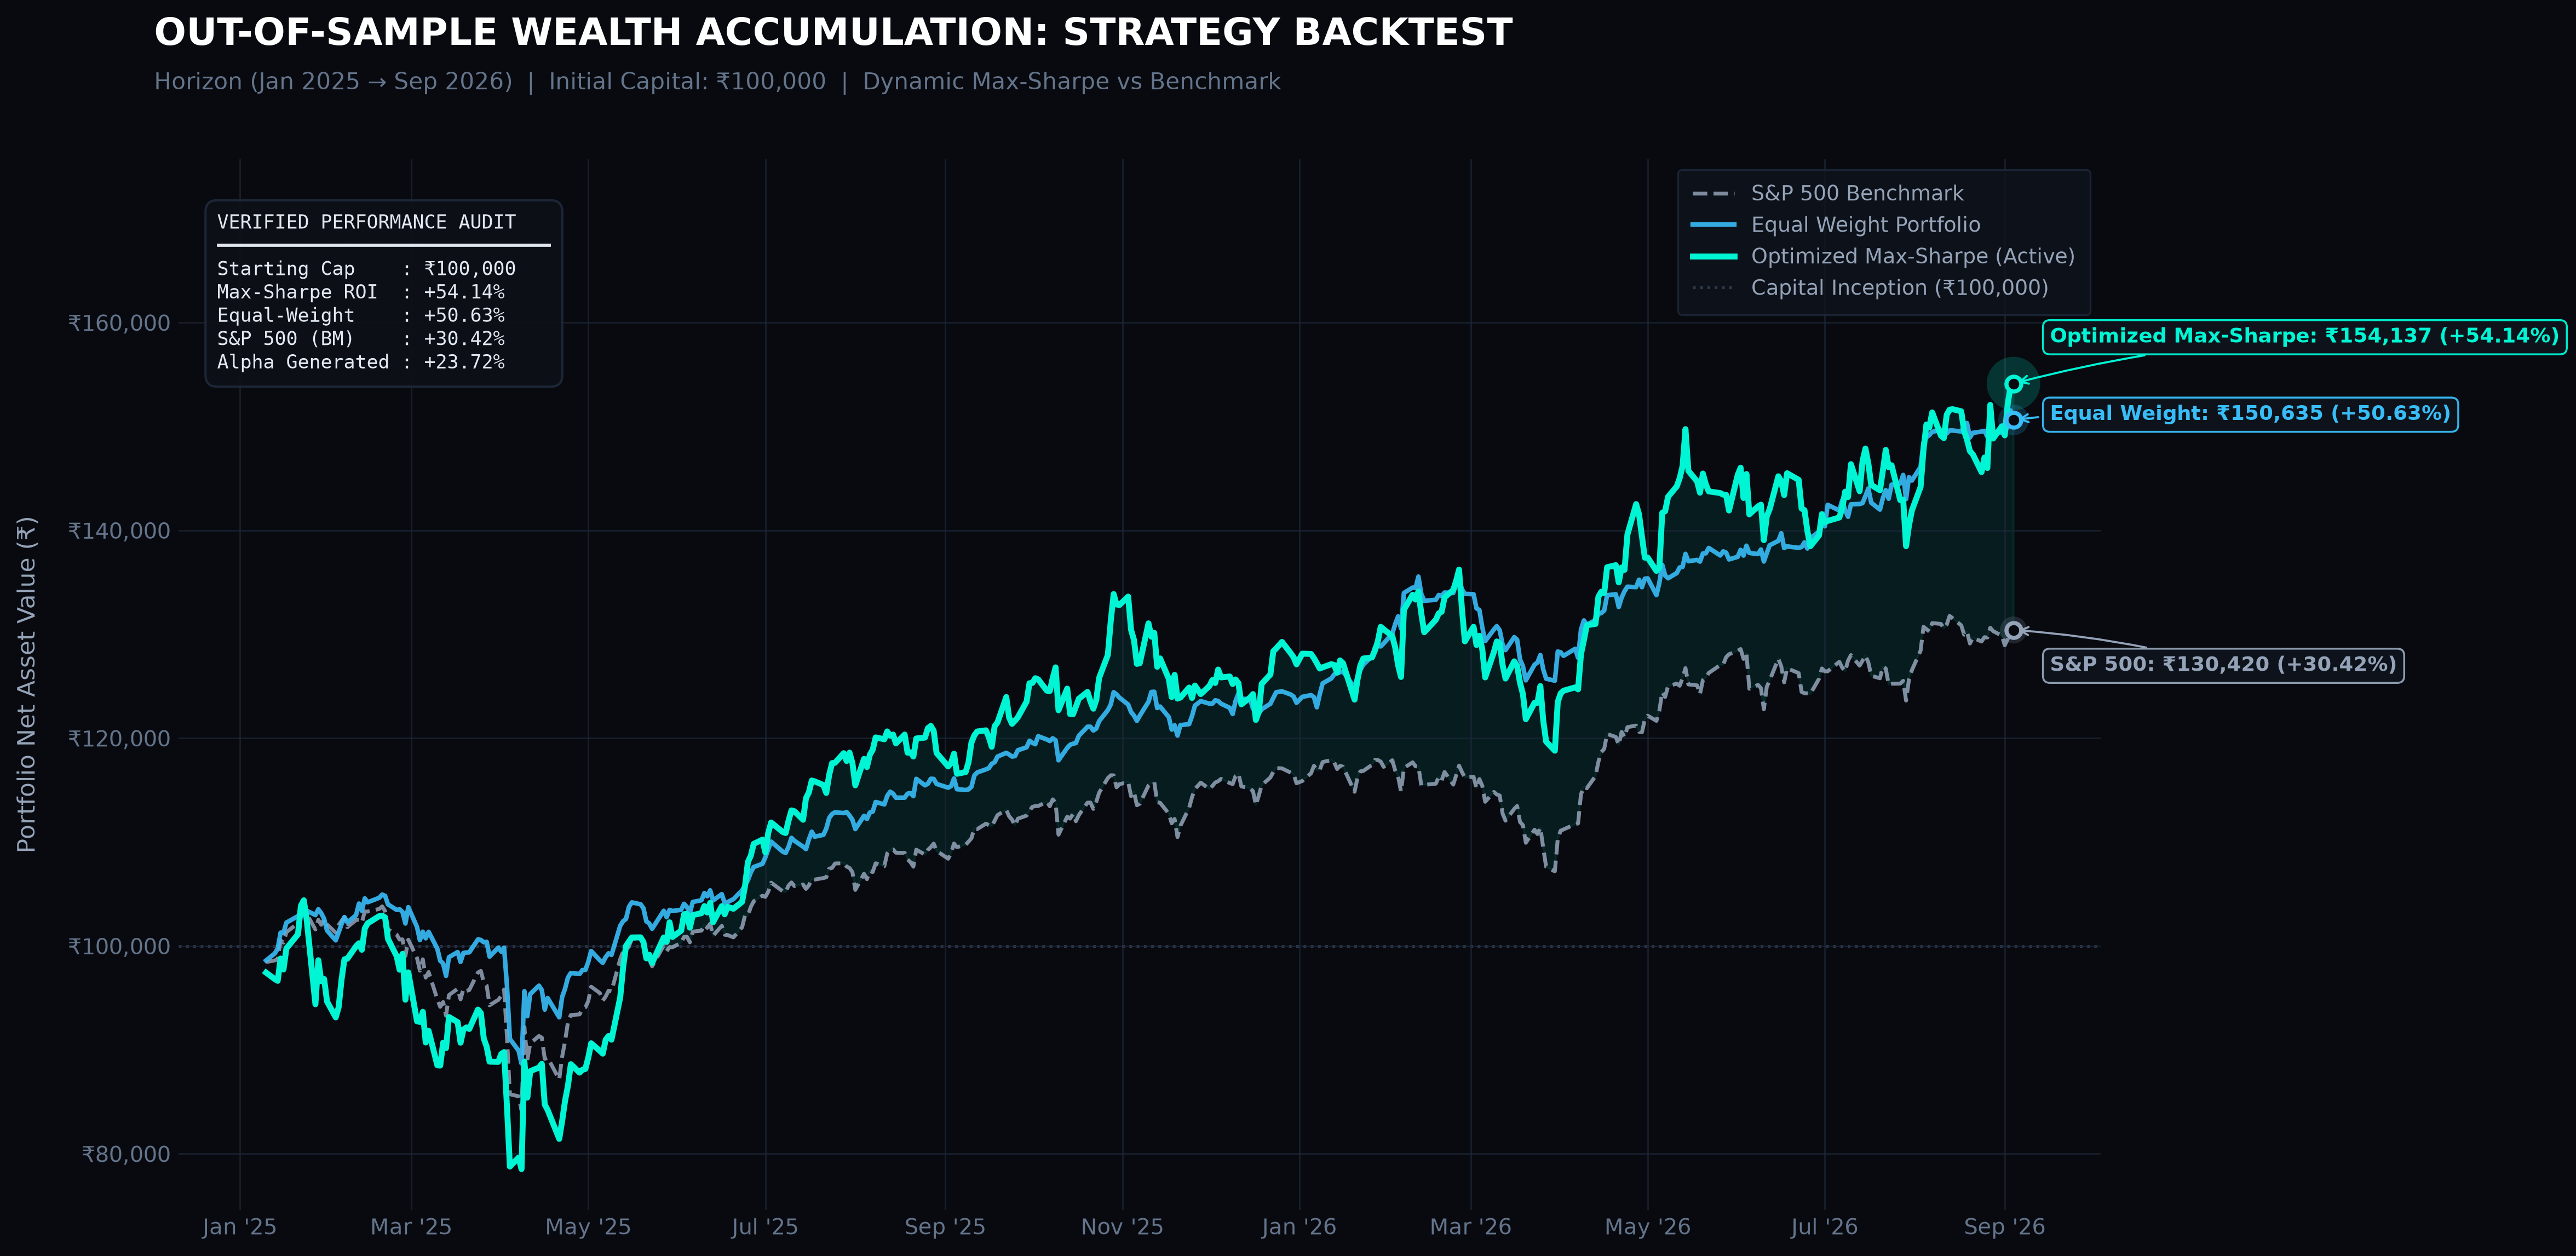

CORRECTED OUT-OF-SAMPLE WEALTH CHART SAVED
Starting capital: ₹100,000.00

Final values and actual verified ROI:
Optimized Max-Sharpe      ₹154,137.14  ROI: +54.14%
Equal Weight              ₹150,634.58  ROI: +50.63%
S&P 500                   ₹130,420.31  ROI: +30.42%

Saved PNG: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\portfolio\oos_cumulative_wealth_comparison_corrected.png
Saved PDF: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\portfolio\oos_cumulative_wealth_comparison_corrected.pdf


In [16]:
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# 1. Canvas Setup & Ground-Truth Capital Anchoring
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(15, 8.2), dpi=300)
fig.patch.set_facecolor("#080A0F")
ax.set_facecolor("#080A0F")

# Construct clean wealth DataFrame
wealth_df = pd.DataFrame({
    "Optimized Max-Sharpe": optimized_wealth,
    "Equal Weight": equal_weight_wealth,
    "S&P 500": benchmark_wealth,})

if not isinstance(wealth_df.index, pd.DatetimeIndex):
    wealth_df.index = pd.to_datetime(wealth_df.index)

dates = wealth_df.index

# STRICT BASELINE: Official Backtest Initial Capital
INITIAL_CAPITAL = 100_000.0

# Colors
c_opt = "#00F5D4"   
c_eq = "#38BDF8"    
c_bm = "#94A3B8"    

# 2. Plot Curves & Inception Parity Line
# S&P 500 Benchmark
ax.plot(
    dates,
    wealth_df["S&P 500"],
    color=c_bm,
    linewidth=1.7,
    linestyle="--",
    alpha=0.85,
    label="S&P 500 Benchmark",
    zorder=2,)

# Equal Weight
ax.plot(
    dates,
    wealth_df["Equal Weight"],
    color=c_eq,
    linewidth=2.0,
    alpha=0.90,
    label="Equal Weight Portfolio",
    zorder=3,)

# Optimized Max-Sharpe
ax.plot(
    dates,
    wealth_df["Optimized Max-Sharpe"],
    color=c_opt,
    linewidth=2.6,
    alpha=1.0,
    label="Optimized Max-Sharpe (Active)",
    zorder=5,)

# Ambient Fill between Active Model & Benchmark
ax.fill_between(
    dates,
    wealth_df["Optimized Max-Sharpe"],
    wealth_df["S&P 500"],
    where=(wealth_df["Optimized Max-Sharpe"] >= wealth_df["S&P 500"]),
    color=c_opt,
    alpha=0.08,
    interpolate=True,
    zorder=1,)

# Inception Capital Line (Guaranteed ₹100,000 reference)
ax.axhline(
    INITIAL_CAPITAL,
    color="#334155",
    linestyle=":",
    linewidth=1.2,
    alpha=0.85,
    label=f"Capital Inception (₹{INITIAL_CAPITAL:,.0f})",
    zorder=1,)

# 3. Exact Backtest ROI Calculations & Endpoint Beads
final_opt = wealth_df["Optimized Max-Sharpe"].iloc[-1]
final_eq = wealth_df["Equal Weight"].iloc[-1]
final_bm = wealth_df["S&P 500"].iloc[-1]

# Calculated directly against INITIAL_CAPITAL (₹100,000)
roi_opt = ((final_opt - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
roi_eq = ((final_eq - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
roi_bm = ((final_bm - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100

endpoints = [
    (final_opt, c_opt, f"Optimized Max-Sharpe: ₹{final_opt:,.0f} (+{roi_opt:.2f}%)", 18, 550),
    (final_eq, c_eq, f"Equal Weight: ₹{final_eq:,.0f} (+{roi_eq:.2f}%)", 0, 180),
    (final_bm, c_bm, f"S&P 500: ₹{final_bm:,.0f} (+{roi_bm:.2f}%)", -18, 140),]

for val, col, text, offset_y, glow_size in endpoints:
    ax.scatter([dates[-1]], [val], s=glow_size, color=col, alpha=0.18, edgecolors="none", zorder=6)
    ax.scatter([dates[-1]], [val], s=42, color="#080A0F", edgecolors=col, linewidths=1.8, zorder=7)

    ax.annotate(
        text,
        xy=(dates[-1], val),
        xytext=(16, offset_y),
        textcoords="offset points",
        fontsize=8.8,
        fontweight="bold",
        color=col,
        bbox=dict(boxstyle="round,pad=0.35", fc="#0F141C", ec=col, lw=0.85, alpha=0.95),
        arrowprops=dict(arrowstyle="->", color=col, lw=0.9, connectionstyle="arc3,rad=0.05"),
        zorder=8,)

# 4. Verified Metrics Audit Badge & Header
fig.text(
    0.06, 0.965,
    "OUT-OF-SAMPLE WEALTH ACCUMULATION: STRATEGY BACKTEST",
    fontsize=16.5, fontweight="heavy", color="#FFFFFF", ha="left")

fig.text(
    0.06, 0.932,
    f"Horizon ({dates[0].strftime('%b %Y')} → {dates[-1].strftime('%b %Y')})  |  Initial Capital: ₹{INITIAL_CAPITAL:,.0f}  |  Dynamic Max-Sharpe vs Benchmark",
    fontsize=10, color="#64748B", ha="left")

alpha_generated = roi_opt - roi_bm
summary_badge = (
    f"VERIFIED PERFORMANCE AUDIT\n"
    f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
    f"Starting Cap    : ₹{INITIAL_CAPITAL:,.0f}\n"
    f"Max-Sharpe ROI  : +{roi_opt:.2f}%\n"
    f"Equal-Weight    : +{roi_eq:.2f}%\n"
    f"S&P 500 (BM)    : +{roi_bm:.2f}%\n"
    f"Alpha Generated : +{alpha_generated:.2f}%")

ax.text(
    0.02, 0.95,
    summary_badge,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=8.5,
    fontfamily="monospace",
    color="#E2E8F0",
    bbox=dict(boxstyle="round,pad=0.6", fc="#0D1117", ec="#1E293B", lw=1.0, alpha=0.92),
    zorder=6,)

# 5. Gridlines, Axes & Limits

ax.grid(True, which="major", color="#1E293B", linestyle="-", linewidth=0.65, alpha=0.7)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", which="both", colors="#64748B", labelsize=9.5, length=0)
ax.set_ylabel("Portfolio Net Asset Value (₹)", color="#94A3B8", fontsize=10.5, labelpad=12)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("₹{x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

min_floor = min(wealth_df.min().min(), INITIAL_CAPITAL) * 0.95
ax.set_ylim(min_floor, max(final_opt, final_eq, final_bm) * 1.14)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="#0F141C",
    edgecolor="#1E293B",
    fontsize=9.2,
    labelcolor="#94A3B8",
    borderpad=0.7,)
legend.get_frame().set_linewidth(0.8)

# 6. Artifact Export (PNG + Vector PDF)

plt.subplots_adjust(top=0.88, bottom=0.10, left=0.07, right=0.85)

RESULTS_DIR = Path(globals().get("PROJECT_ROOT", ".")) / "results" / "portfolio"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

wealth_path = RESULTS_DIR / "oos_cumulative_wealth_comparison_corrected.png"
wealth_pdf = RESULTS_DIR / "oos_cumulative_wealth_comparison_corrected.pdf"

plt.savefig(wealth_path, dpi=300, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")
plt.savefig(wealth_pdf, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")

plt.show()
plt.close()

# 7. Verification Audit Print

print("=" * 75)
print("CORRECTED OUT-OF-SAMPLE WEALTH CHART SAVED")
print("=" * 75)
print(f"Starting capital: ₹{INITIAL_CAPITAL:,.2f}")
print("\nFinal values and actual verified ROI:")
for col, final_val, roi_val in [
    ("Optimized Max-Sharpe", final_opt, roi_opt),
    ("Equal Weight", final_eq, roi_eq),
    ("S&P 500", final_bm, roi_bm),
]:
    print(f"{col:25} ₹{final_val:,.2f}  ROI: {roi_val:+.2f}%")

print(f"\nSaved PNG: {wealth_path.resolve()}")
print(f"Saved PDF: {wealth_pdf.resolve()}")

In [17]:
# MPT FINAL EXPORT — RESEARCH RESULTS PACKAGE

from pathlib import Path
import pandas as pd
import numpy as np

# Output directory

PORTFOLIO_DIR = (
    PROJECT_ROOT / "results" / "portfolio")

PORTFOLIO_DIR.mkdir(
    parents=True,
    exist_ok=True)

# 1. Optimized portfolio weights

optimized_weights_export = pd.DataFrame({
    "Ticker": stocks,
    "Weight": optimized_weights,
    "Weight_%": optimized_weights * 100})

optimized_weights_export.to_csv(
    PORTFOLIO_DIR / "optimized_max_sharpe_weights.csv",
    index=False)

# 2. Full-sample MPT comparison

full_sample_export = comparison.copy()

full_sample_export.to_csv(
    PORTFOLIO_DIR / "full_sample_mpt_comparison.csv")

# 3. Full-sample risk metrics

risk_metrics_export = risk_metrics.copy()

risk_metrics_export.to_csv(
    PORTFOLIO_DIR / "full_sample_risk_metrics.csv")

# 4. Out-of-sample metrics

oos_metrics_export = oos_metrics.copy()

oos_metrics_export.to_csv(
    PORTFOLIO_DIR / "oos_portfolio_metrics.csv")

# 5. Out-of-sample final values

final_values_export = final_values.copy()

final_values_export.to_csv(
    PORTFOLIO_DIR / "oos_final_portfolio_values.csv")

# 6. Monte Carlo summary

monte_carlo_summary = pd.DataFrame({
    "Metric": [
        "Number of Portfolios",
        "Best Random Sharpe",
        "Best Random Annual Return",
        "Best Random Annual Volatility",
        "Minimum Volatility",
        "Minimum Volatility Portfolio Return",
        "Minimum Volatility Portfolio Sharpe"
    ],
    "Value": [
        N_PORTFOLIOS,
        best_random_portfolio["Sharpe_Ratio"],
        best_random_portfolio["Annual_Return"],
        best_random_portfolio["Annual_Volatility"],
        lowest_vol_portfolio["Annual_Volatility"],
        lowest_vol_portfolio["Annual_Return"],
        lowest_vol_portfolio["Sharpe_Ratio"]]})

monte_carlo_summary.to_csv(
    PORTFOLIO_DIR / "monte_carlo_summary.csv",
    index=False)

# 7. OOS wealth series

wealth_df.to_csv(
    PORTFOLIO_DIR / "oos_wealth_series.csv")

# 8. MPT research summary

research_summary = pd.DataFrame({
    "Metric": [
        "Portfolio Universe",
        "Historical Period",
        "OOS Test Period",
        "Monte Carlo Portfolios",
        "Risk-Free Rate",
        "Optimized Annual Return (Full Sample)",
        "Optimized Volatility (Full Sample)",
        "Optimized Sharpe (Full Sample)",
        "Optimized OOS Total Return",
        "Equal Weight OOS Total Return",
        "S&P 500 OOS Total Return"],

    "Value": [
        ", ".join(stocks),
        f"{returns_risk.index.min().date()} → {returns_risk.index.max().date()}",
        f"{test_returns.index.min().date()} → {test_returns.index.max().date()}",
        N_PORTFOLIOS,
        rf,
        optimized_return,
        optimized_volatility,
        optimized_sharpe,
        oos_metrics.loc["Optimized Max-Sharpe", "Total Return"],
        oos_metrics.loc["Equal Weight", "Total Return"],
        oos_metrics.loc["S&P 500", "Total Return"]]})

research_summary.to_csv(
    PORTFOLIO_DIR / "mpt_research_summary.csv",
    index=False)

# 9. Print final package

print("=" * 75)
print("MPT — FINAL RESEARCH RESULTS EXPORTED")
print("=" * 75)

exported_files = [
    "optimized_max_sharpe_weights.csv",
    "full_sample_mpt_comparison.csv",
    "full_sample_risk_metrics.csv",
    "oos_portfolio_metrics.csv",
    "oos_final_portfolio_values.csv",
    "monte_carlo_summary.csv",
    "oos_wealth_series.csv",
    "mpt_research_summary.csv",
    "efficient_frontier_monte_carlo.png",
    "oos_cumulative_wealth_comparison_corrected.png"]

for filename in exported_files:
    path = PORTFOLIO_DIR / filename
    status = "✅" if path.exists() else "⚠️"
    print(f"{status} {filename}")

print("\nMPT results directory:")
print(PORTFOLIO_DIR)

MPT — FINAL RESEARCH RESULTS EXPORTED
✅ optimized_max_sharpe_weights.csv
✅ full_sample_mpt_comparison.csv
✅ full_sample_risk_metrics.csv
✅ oos_portfolio_metrics.csv
✅ oos_final_portfolio_values.csv
✅ monte_carlo_summary.csv
✅ oos_wealth_series.csv
✅ mpt_research_summary.csv
✅ efficient_frontier_monte_carlo.png
✅ oos_cumulative_wealth_comparison_corrected.png

MPT results directory:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\portfolio
